### Fig. 2G: visualization of Hi-C linkage pairs between viral contigs and MAGs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## viral contigs

df_v = pd.read_csv('../data/all_viral-info.tsv', sep='\t')

## MAG contigs

df_c = pd.read_csv('../data/SPMP_MAG_contig-info.tsv', sep='\t')

## rescale lengths for plotting

L = 1000

VFC 1 vOTU (TLL99_opera_contig_144) with broad Hi-C linkages to 2 host MAGs from different orders

In [2]:
## specify viral contig and host MAGs

v='TLL94_opera_contig_225'
b1='TLL94_bin.130'; b11 = r'CAG\text{-}110\ sp900546915'
b2='TLL94_bin.137'; b21 = r'Dorea\ formicigenerans'

## viral contig length

vir_len = df_v.loc[df_v.vir_id == v, 'vir_len'].values[0]

## MAG contig lengths and cumulative positions

df_c1 = df_c.loc[df_c.mag_id == b1].sort_values('contig_len', ascending=False)
df_c2 = df_c.loc[df_c.mag_id == b2].sort_values('contig_len', ascending=False)

df_c1['start'] = df_c1['contig_len'].cumsum() - df_c1['contig_len']
df_c1['end'] = df_c1['contig_len'].cumsum()

df_c2['start'] = df_c2['contig_len'].cumsum() - df_c2['contig_len']
df_c2['end'] = df_c2['contig_len'].cumsum()

host1_len = df_c1['end'].max()
host2_len = df_c2['end'].max()

## Hi-C mapping positions between viral contig and host MAGs

df_map1 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b1}-HiCpos.tsv', sep='\t')
df_map2 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b2}-HiCpos.tsv', sep='\t')

df_map11 = df_map1.merge(df_c1[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map11['global_pos'] = df_map11['start'] + df_map11['pos2']

df_map21 = df_map2.merge(df_c2[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map21['global_pos'] = df_map21['start'] + df_map21['pos2']

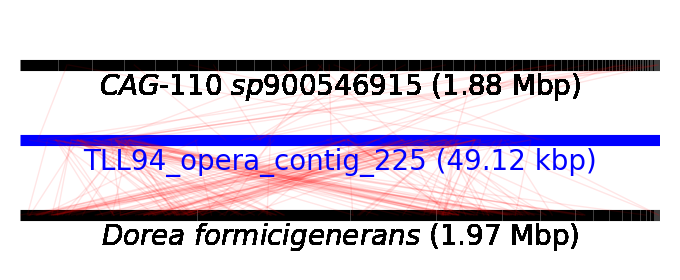

In [3]:
# rescale lengths
vir_scale = L / vir_len
host1_scale = L / host1_len
host2_scale = L / host2_len

fig, ax = plt.subplots(figsize=(3.5, 1.5), dpi=200)

# top track
for _, row in df_c1.iterrows():
    ax.plot([row['start'] * host1_scale, row['end'] * host1_scale], [0.5, 0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host1_len * host1_scale) / 2, .3,
        rf'$\mathit{{{b11}}}$ ({round(host1_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle track
ax.plot([0, vir_len * vir_scale], [0, 0],
        color='blue', lw=4, solid_capstyle='butt')
ax.text((vir_len * vir_scale) / 2, -0.2,
        f'{v} ({round(vir_len / 1e3, 2)} kbp)', ha='center', color='blue')

# top-to-middle connecting lines
for _, row in df_map11.iterrows():
    host_pos_scaled = row['global_pos'] * host1_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

# bottom track
for _, row in df_c2.iterrows():
    ax.plot([row['start'] * host2_scale, row['end'] * host2_scale], [-0.5, -0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host2_len * host2_scale) / 2, -.7,
        rf'$\mathit{{{b21}}}$ ({round(host2_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle-to-bottom connecting lines
for _, row in df_map21.iterrows():
    host_pos_scaled = row['global_pos'] * host2_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [-0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

ax.set_xlim(0, L)
ax.set_ylim(-.8, .8)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')

plt.tight_layout()
sns.despine(left=True, bottom=True)

VFC 1 vOTU (TLL94_opera_contig_225) with broad Hi-C linkages to 3 host MAGs from 2 different families

In [4]:
## specify viral contig and host MAGs

v = 'TLL99_opera_contig_144'
b1 = 'TLL99_bin.89'; b11 = r'Ruminococcus\_D\ bicirculans'
b2 = 'TLL99_bin.91'; b21 = r'CAG\text{-}103\ sp000432375'

## viral contig length

vir_len = df_v.loc[df_v.vir_id == v, 'vir_len'].values[0]

## MAG contig lengths and cumulative positions

df_c1 = df_c.loc[df_c.mag_id == b1].sort_values('contig_len', ascending=False)
df_c2 = df_c.loc[df_c.mag_id == b2].sort_values('contig_len', ascending=False)

df_c1['start'] = df_c1['contig_len'].cumsum() - df_c1['contig_len']
df_c1['end'] = df_c1['contig_len'].cumsum()

df_c2['start'] = df_c2['contig_len'].cumsum() - df_c2['contig_len']
df_c2['end'] = df_c2['contig_len'].cumsum()

host1_len = df_c1['end'].max()
host2_len = df_c2['end'].max()

## Hi-C mapping positions between viral contig and host MAGs

df_map1 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b1}-HiCpos.tsv', sep='\t')
df_map2 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b2}-HiCpos.tsv', sep='\t')

df_map11 = df_map1.merge(df_c1[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map11['global_pos'] = df_map11['start'] + df_map11['pos2']

df_map21 = df_map2.merge(df_c2[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map21['global_pos'] = df_map21['start'] + df_map21['pos2']

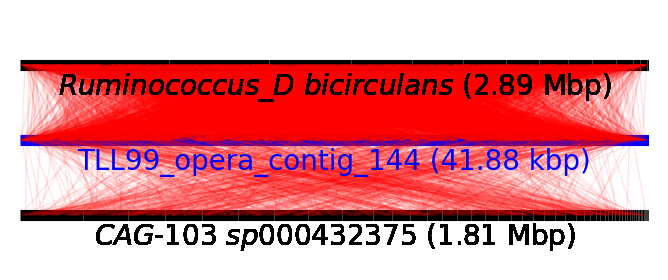

In [5]:
# rescale lengths
vir_scale = L / vir_len
host1_scale = L / host1_len
host2_scale = L / host2_len

fig, ax = plt.subplots(figsize=(3.5, 1.5), dpi=200)

# top track
for _, row in df_c1.iterrows():
    ax.plot([row['start'] * host1_scale, row['end'] * host1_scale], [0.5, 0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host1_len * host1_scale) / 2, .3,
        rf'$\mathit{{{b11}}}$ ({round(host1_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle track
ax.plot([0, vir_len * vir_scale], [0, 0],
        color='blue', lw=4, solid_capstyle='butt')
ax.text((vir_len * vir_scale) / 2, -0.2,
        f'{v} ({round(vir_len / 1e3, 2)} kbp)', ha='center', color='blue')

# top-to-middle connecting lines
for _, row in df_map11.iterrows():
    host_pos_scaled = row['global_pos'] * host1_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

# bottom track
for _, row in df_c2.iterrows():
    ax.plot([row['start'] * host2_scale, row['end'] * host2_scale], [-0.5, -0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host2_len * host2_scale) / 2, -.7,
        rf'$\mathit{{{b21}}}$ ({round(host2_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle-to-bottom connecting lines
for _, row in df_map21.iterrows():
    host_pos_scaled = row['global_pos'] * host2_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [-0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

ax.set_xlim(0, L)
ax.set_ylim(-.8, .8)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')

plt.tight_layout()
sns.despine(left=True, bottom=True)

In [6]:
## specify viral contig and host MAGs

v = 'TLL99_opera_contig_144'
b1 = 'TLL99_bin.89'; b11 = r'Ruminococcus\_D\ bicirculans'
b2 = 'TLL99_bin.54'; b21 = r'CAG\text{-}83\ sp001916855'

## viral contig length

vir_len = df_v.loc[df_v.vir_id == v, 'vir_len'].values[0]

## MAG contig lengths and cumulative positions

df_c1 = df_c.loc[df_c.mag_id == b1].sort_values('contig_len', ascending=False)
df_c2 = df_c.loc[df_c.mag_id == b2].sort_values('contig_len', ascending=False)

df_c1['start'] = df_c1['contig_len'].cumsum() - df_c1['contig_len']
df_c1['end'] = df_c1['contig_len'].cumsum()

df_c2['start'] = df_c2['contig_len'].cumsum() - df_c2['contig_len']
df_c2['end'] = df_c2['contig_len'].cumsum()

host1_len = df_c1['end'].max()
host2_len = df_c2['end'].max()

## Hi-C mapping positions between viral contig and host MAGs

df_map1 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b1}-HiCpos.tsv', sep='\t')
df_map2 = pd.read_csv(f'../data/HiC_mapping_positions/{v}-{b2}-HiCpos.tsv', sep='\t')

df_map11 = df_map1.merge(df_c1[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map11['global_pos'] = df_map11['start'] + df_map11['pos2']

df_map21 = df_map2.merge(df_c2[['contig_id', 'contig_len', 'start']], left_on='contig_id2', right_on='contig_id')
df_map21['global_pos'] = df_map21['start'] + df_map21['pos2']

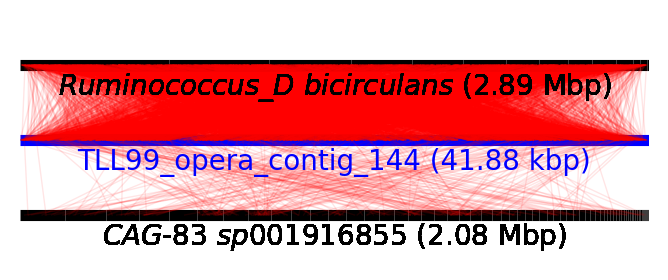

In [7]:
# rescale lengths
vir_scale = L / vir_len
host1_scale = L / host1_len
host2_scale = L / host2_len

fig, ax = plt.subplots(figsize=(3.5, 1.5), dpi=200)

# top track
for _, row in df_c1.iterrows():
    ax.plot([row['start'] * host1_scale, row['end'] * host1_scale], [0.5, 0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host1_len * host1_scale) / 2, .3,
        rf'$\mathit{{{b11}}}$ ({round(host1_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle track
ax.plot([0, vir_len * vir_scale], [0, 0],
        color='blue', lw=4, solid_capstyle='butt')
ax.text((vir_len * vir_scale) / 2, -0.2,
        f'{v} ({round(vir_len / 1e3, 2)} kbp)', ha='center', color='blue')

# top-to-middle connecting lines
for _, row in df_map11.iterrows():
    host_pos_scaled = row['global_pos'] * host1_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

# bottom track
for _, row in df_c2.iterrows():
    ax.plot([row['start'] * host2_scale, row['end'] * host2_scale], [-0.5, -0.5],
            color='black', lw=4, solid_capstyle='butt')
    ax.text((host2_len * host2_scale) / 2, -.7,
        rf'$\mathit{{{b21}}}$ ({round(host2_len / 1e6, 2)} Mbp)', ha='center', color='black', usetex=False)

# middle-to-bottom connecting lines
for _, row in df_map21.iterrows():
    host_pos_scaled = row['global_pos'] * host2_scale
    virus_pos_scaled = row['pos1'] * vir_scale
    ax.plot([host_pos_scaled, virus_pos_scaled], [-0.5, 0],
            color='red', alpha=0.1, linewidth=0.5)

ax.set_xlim(0, L)
ax.set_ylim(-.8, .8)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')

plt.tight_layout()
sns.despine(left=True, bottom=True)